In [9]:
import pandas as pd
from bsse_calculator.plotting_helpers import (
    make_bsse_contour_plots,
    fit_gaussian,
    make_contour_plots_of_fitted_gaussian,
    predicted_v_actual_plot,
    make_error_contour_plots,
)

In [10]:
data = pd.read_csv("BSSE_by_H2O_H2O_distance_nwchem_more_distances_extra.csv")

In [11]:
total_energies = pd.DataFrame()
for column in data.columns:
    if "Total_energy" in column:
        total_energies[column.replace("Total_energy_", "")] = data[column].apply(
            lambda x: float(x.strip("()").split(",")[0])
        )
total_energies["x"] = data["x"]
total_energies["y"] = data["y"]
total_energies["z"] = data["z"]
total_energies

,Delta_E_AB_AB,BSSE_A,BSSE_B,x,y,z
0,0.063964,0.001799,0.001949,0.25,1.00,1.75
1,0.039308,0.001453,0.001557,0.25,1.25,1.75
2,0.044595,0.001574,0.001751,0.25,1.50,1.50
3,0.022116,0.001129,0.001188,0.25,1.50,1.75
4,0.089844,0.002220,0.002483,0.25,1.75,1.00
...,...,...,...,...,...,...
141,0.003324,0.000892,0.001429,1.75,1.75,0.75
142,0.000782,0.000767,0.001171,1.75,1.75,1.00
143,-0.000770,0.000648,0.000913,1.75,1.75,1.25
144,-0.001446,0.000549,0.000690,1.75,1.75,1.50


In [12]:
extra_data = pd.read_csv("BSSE_by_H2O_H2O_distance_nwchem_more_distances.csv")

In [13]:
bsse_data_nwchem_kcal = pd.concat([total_energies, extra_data], ignore_index=True)
bsse_data_nwchem_kcal["BSSE_A"] = bsse_data_nwchem_kcal["BSSE_A"] * 627.5096
bsse_data_nwchem_kcal["BSSE_B"] = bsse_data_nwchem_kcal["BSSE_B"] * 627.5096
bsse_data_nwchem_kcal["Delta_E_AB_AB"] = (
    bsse_data_nwchem_kcal["Delta_E_AB_AB"] * 627.5096
)

([<matplotlib.collections.PathCollection at 0x1719821d0>,
 ['Interaction Energy', 'BSSE'])

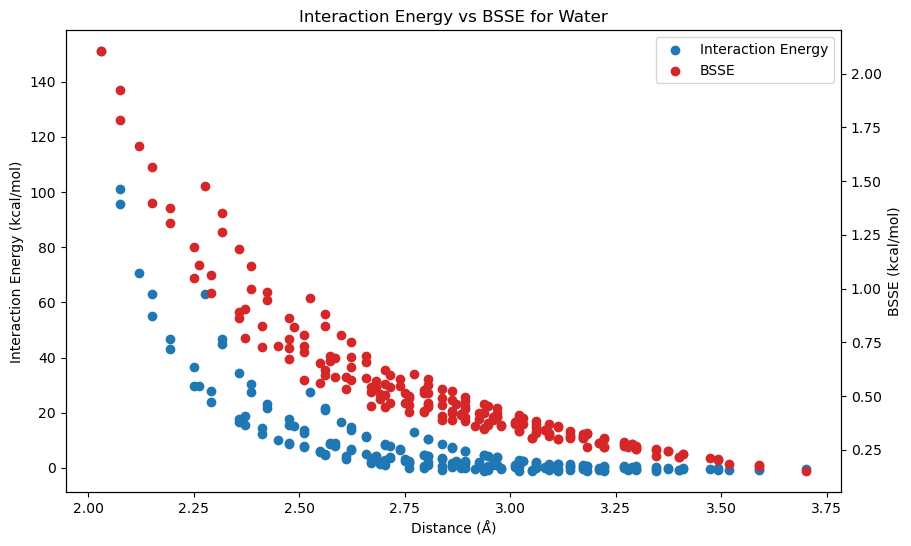

In [6]:
from bsse_calculator.plotting_helpers import *

bsse_data_nwchem_kcal = pd.read_csv(
    "BSSE_by_H2O_H2O_distance_nwchem_more_distances.csv"
)
bsse_data_nwchem_kcal["BSSE_A"] = bsse_data_nwchem_kcal["BSSE_A"] * 627.5096
bsse_data_nwchem_kcal["BSSE_B"] = bsse_data_nwchem_kcal["BSSE_B"] * 627.5096
bsse_data_nwchem_kcal["Delta_E_AB_AB"] = (
    bsse_data_nwchem_kcal["Delta_E_AB_AB"] * 627.5096
)
import numpy as np

bsse_data_nwchem_kcal["distance"] = np.sqrt(
    bsse_data_nwchem_kcal["x"] ** 2
    + bsse_data_nwchem_kcal["y"] ** 2
    + bsse_data_nwchem_kcal["z"] ** 2
)
bsse_data_nwchem_kcal = bsse_data_nwchem_kcal.sort_values("distance")
plot_dual_axis(
    bsse_data_nwchem_kcal["Delta_E_AB_AB"],
    bsse_data_nwchem_kcal["BSSE_A"],
    bsse_data_nwchem_kcal["distance"],
    type="scatter",
    x_label="Distance (Å)",
    y1_label="Interaction Energy (kcal/mol)",
    y2_label="BSSE (kcal/mol)",
    title="Interaction Energy vs BSSE for Water",
    label1="Interaction Energy",
    label2="BSSE",
)

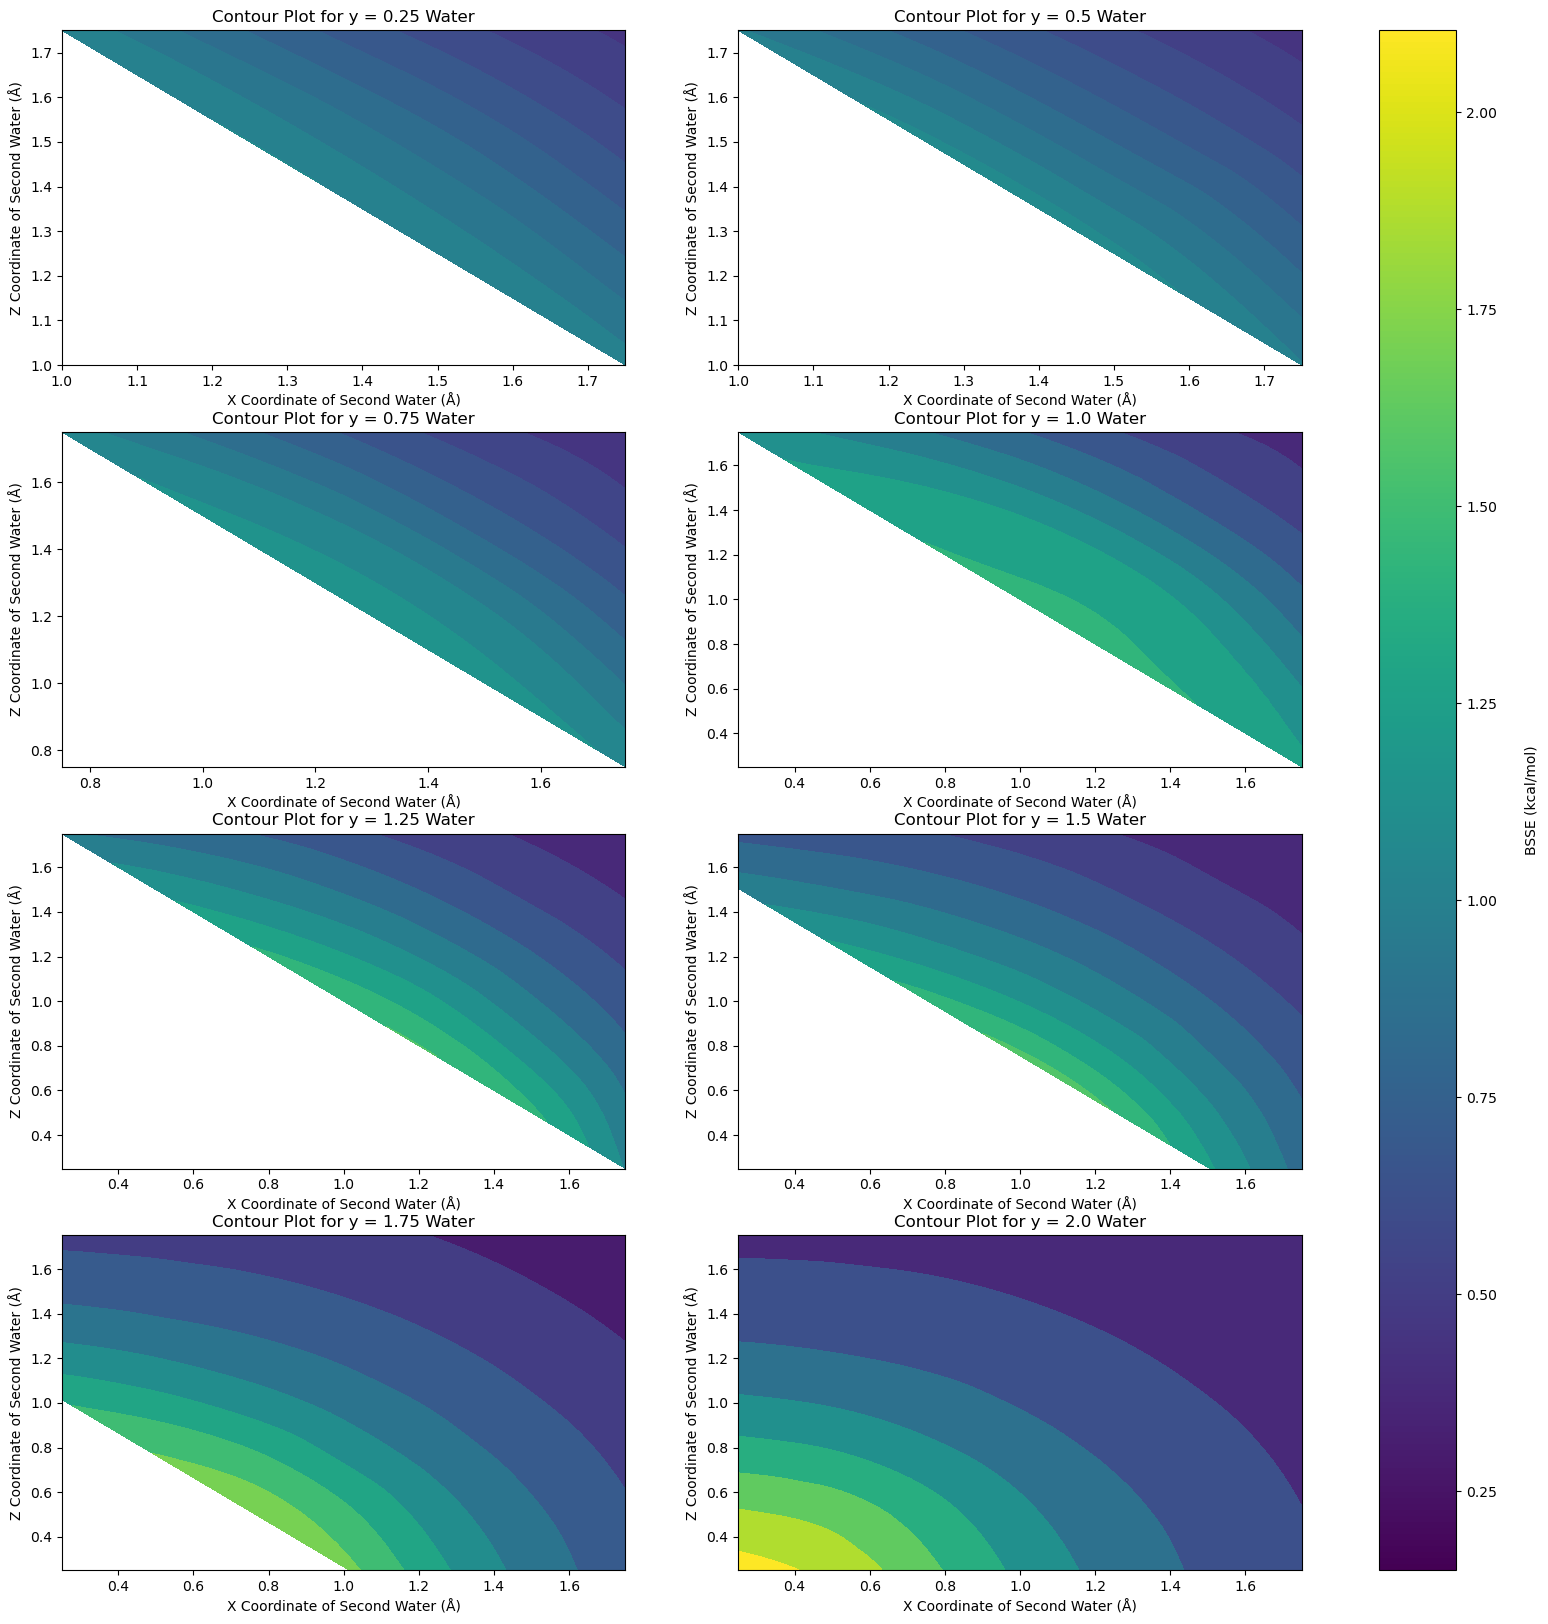

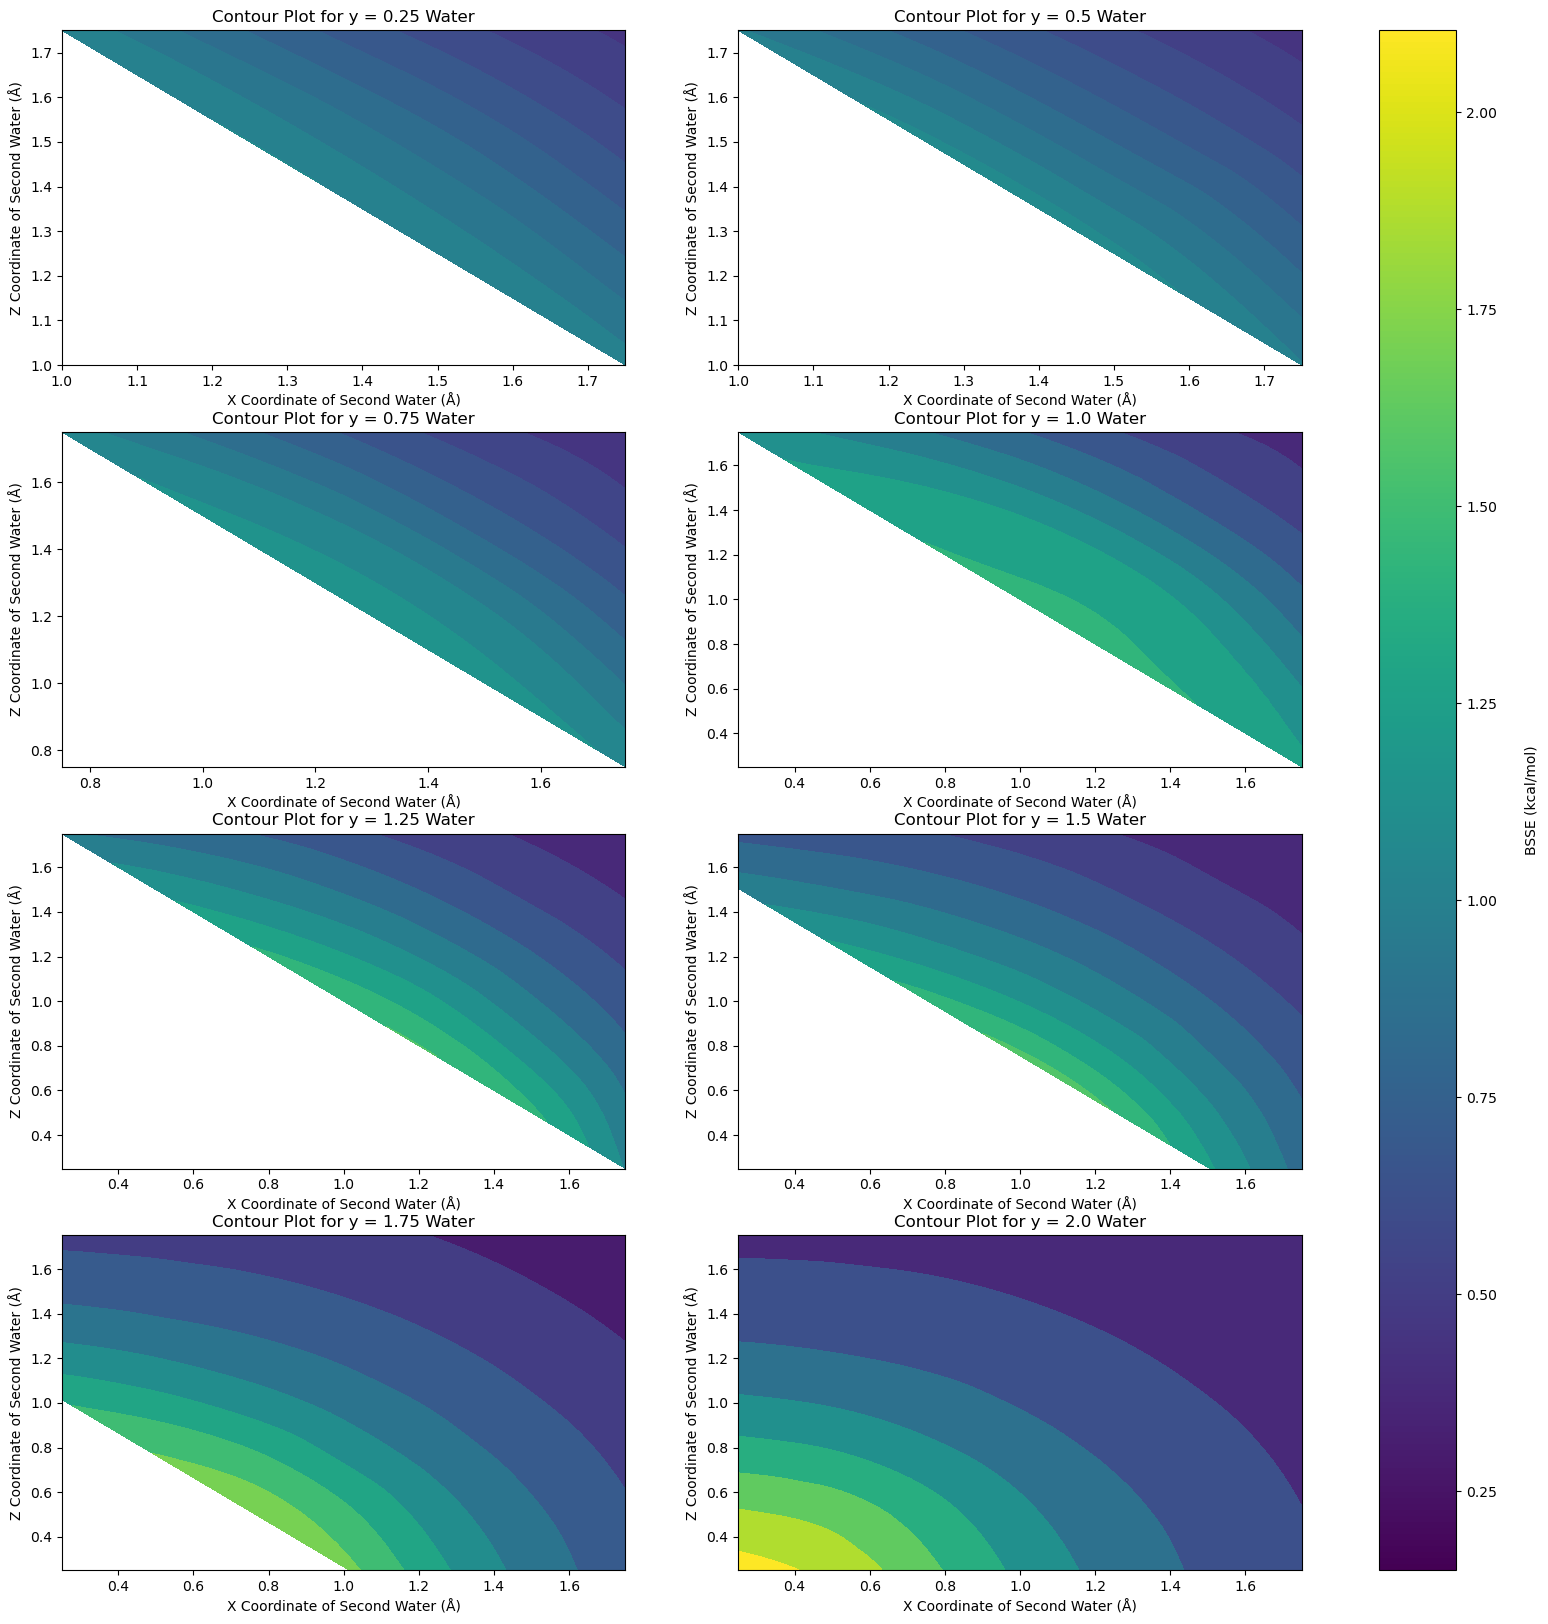

In [15]:
make_bsse_contour_plots(bsse_data_nwchem_kcal, "Water", "Water")

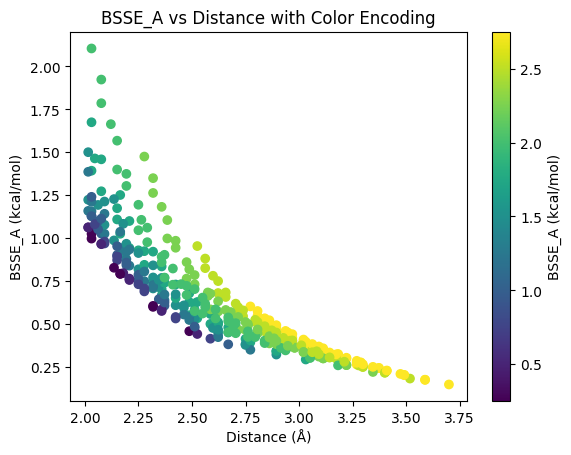

In [26]:
import matplotlib.pyplot as plt

# Compute distance if not already done
bsse_data_nwchem_kcal["distance"] = (
    bsse_data_nwchem_kcal["x"] ** 2
    + bsse_data_nwchem_kcal["y"] ** 2
    + bsse_data_nwchem_kcal["z"] ** 2
) ** 0.5

# Create scatter plot with color based on BSSE_A
sc = plt.scatter(
    bsse_data_nwchem_kcal["distance"],
    bsse_data_nwchem_kcal["BSSE_A"],
    c=bsse_data_nwchem_kcal["y"],
    cmap="viridis",
)

# Add colorbar
plt.colorbar(sc, label="BSSE_A (kcal/mol)")

# Optional: axis labels and title
plt.xlabel("Distance (Å)")
plt.ylabel("BSSE_A (kcal/mol)")
plt.title("BSSE_A vs Distance with Color Encoding")

plt.show()

In [22]:
fit_gauss = fit_gaussian(bsse_data_nwchem_kcal, 4)

/Users/ibrahims/Documents/Programming/undergrad_reasearch/ames_research_summer_2025/psi4/docstring_stuff/src/bsse_calculator/plotting_helpers.py:75: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff, var_matrix = curve_fit(gauss, coords, bsses, p0=p0, maxfev=10000)


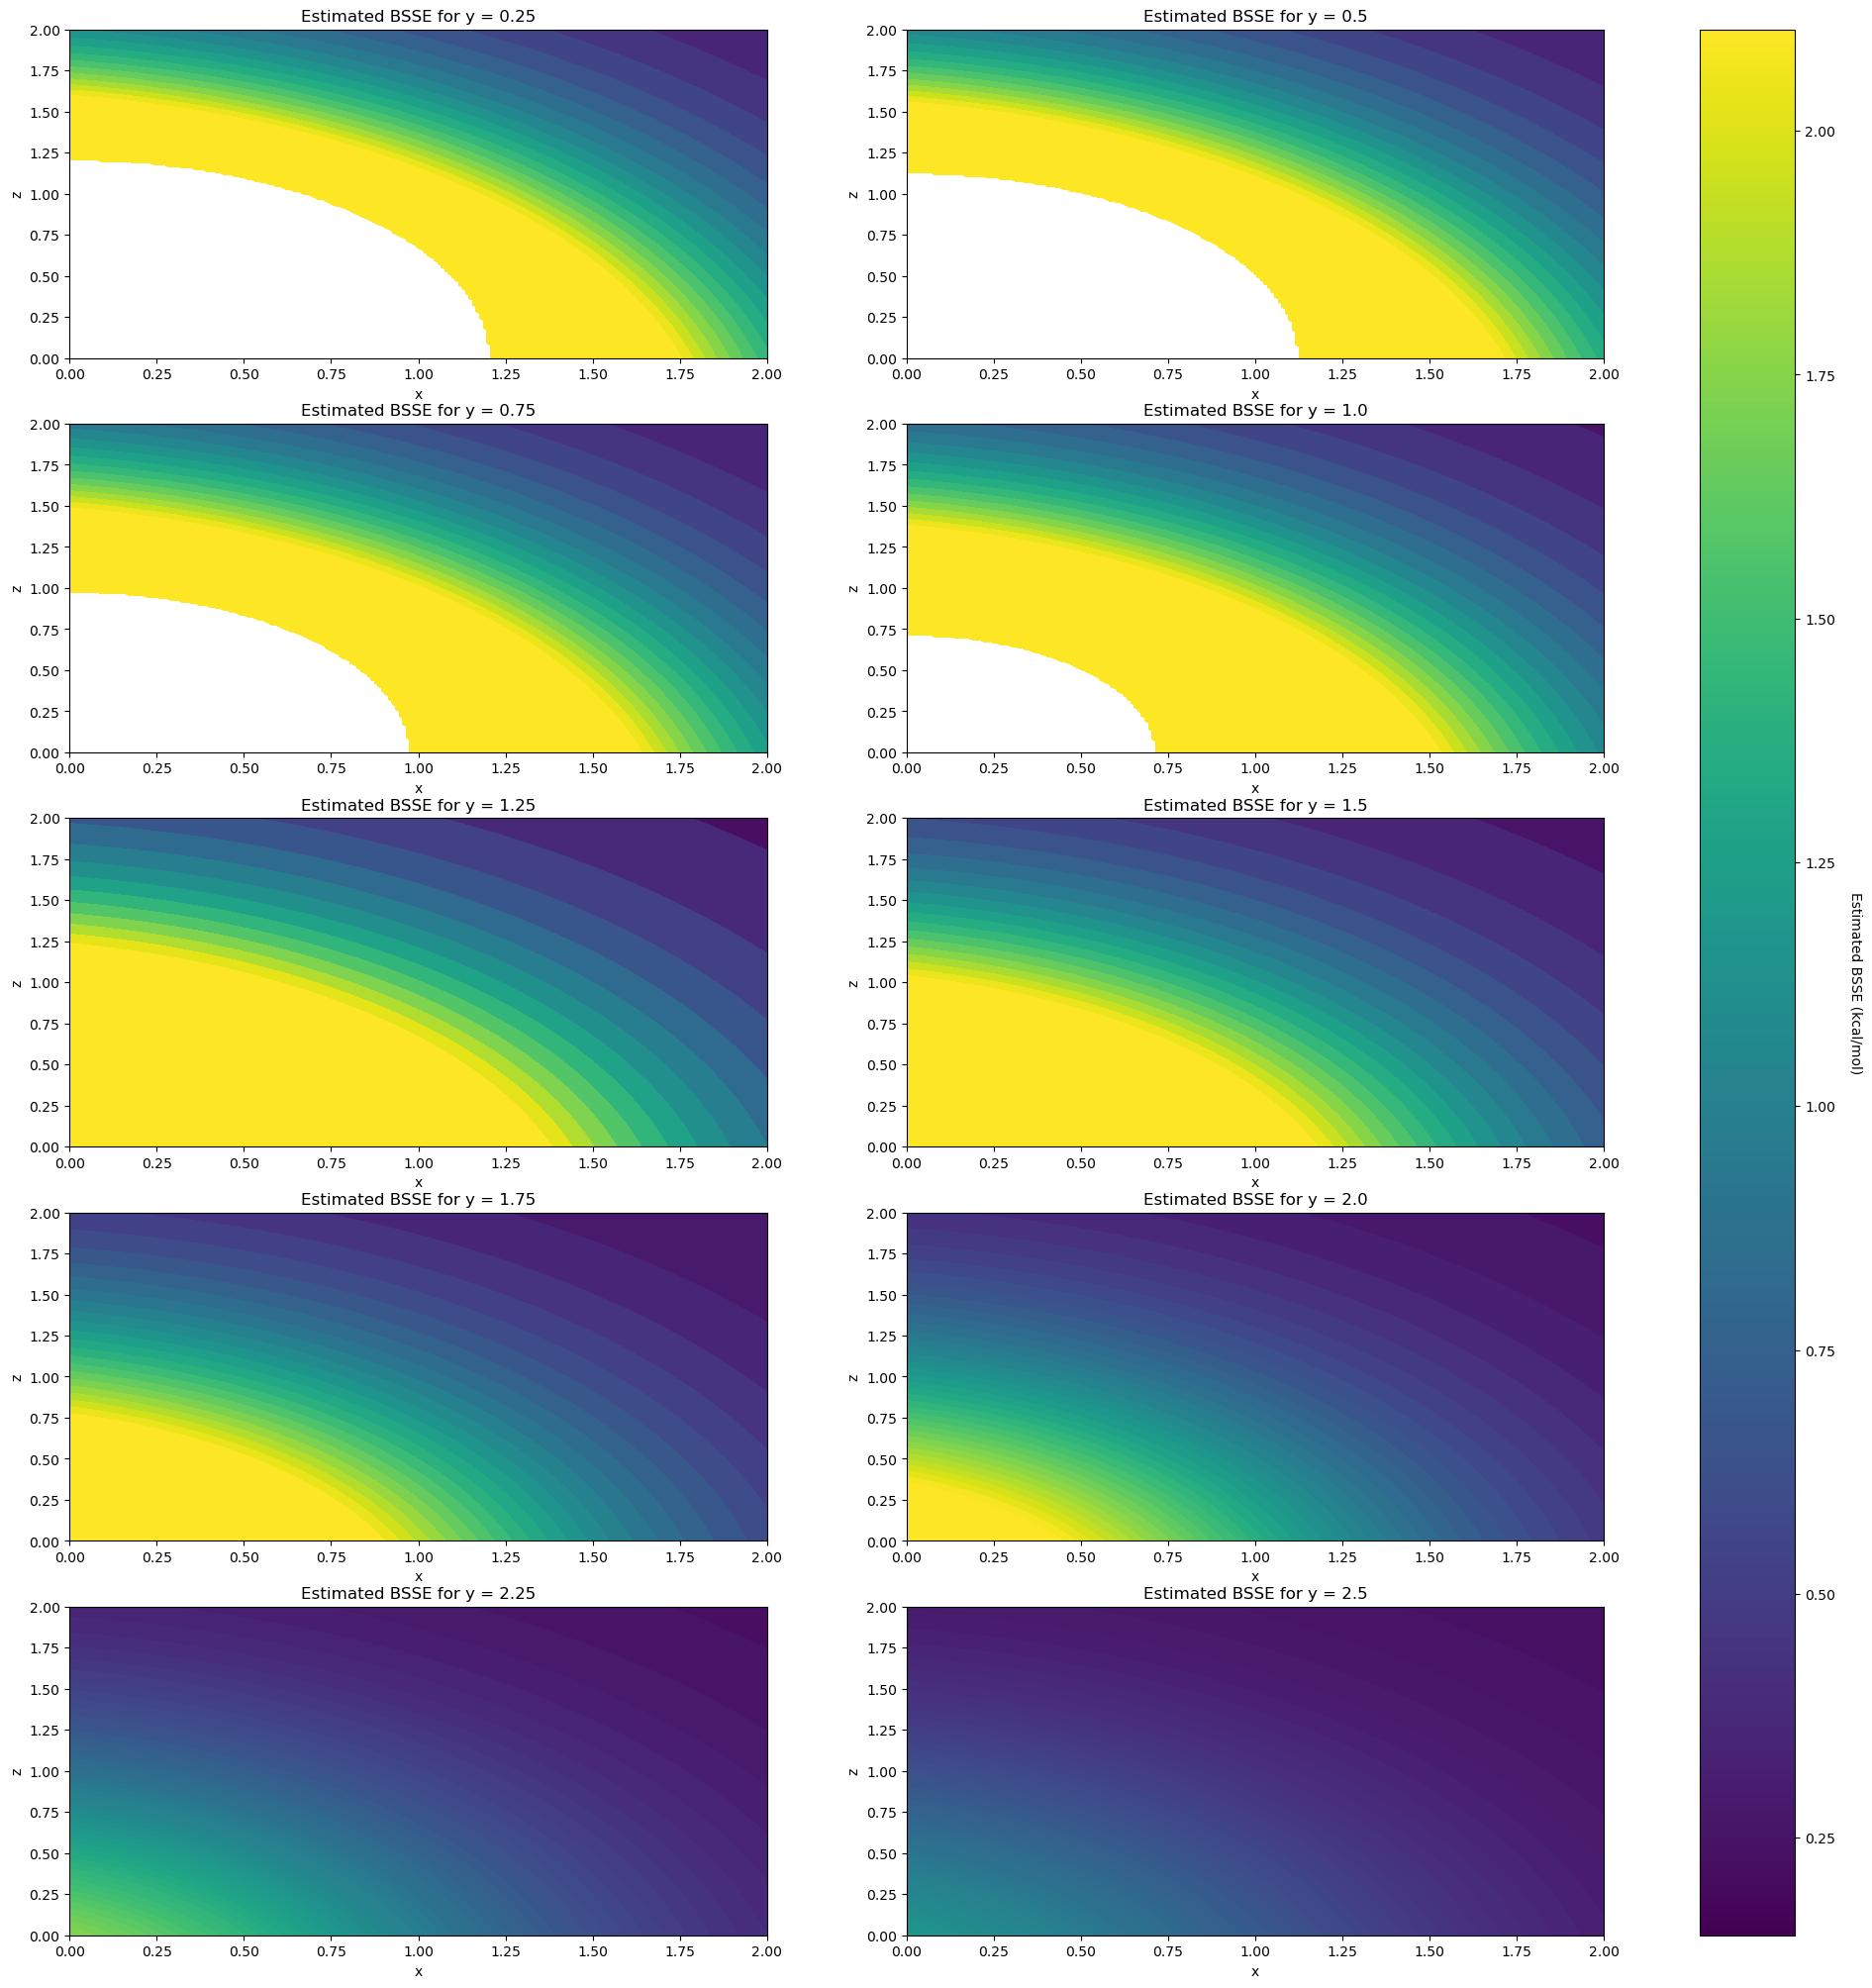

In [17]:
make_contour_plots_of_fitted_gaussian(bsse_data_nwchem_kcal, fit_gauss)

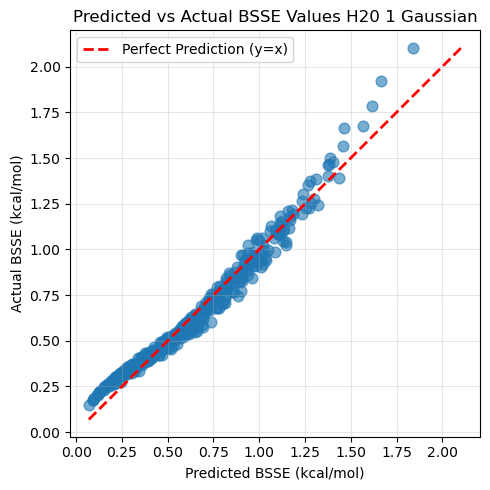

{'RMSE': np.float64(0.060130944238873454), 'MAE': np.float64(0.046865400981888024), '% Error': np.float64(9.785215541653443)}


/Users/ibrahims/Documents/Programming/undergrad_reasearch/ames_research_summer_2025/psi4/docstring_stuff/src/bsse_calculator/plotting_helpers.py:75: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff, var_matrix = curve_fit(gauss, coords, bsses, p0=p0, maxfev=10000)


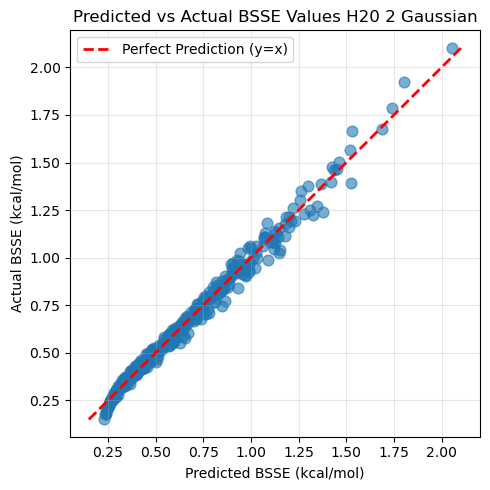

{'RMSE': np.float64(0.03637056878607365), 'MAE': np.float64(0.02663716063158035), '% Error': np.float64(4.5710288143050715)}


/Users/ibrahims/Documents/Programming/undergrad_reasearch/ames_research_summer_2025/psi4/docstring_stuff/src/bsse_calculator/plotting_helpers.py:75: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff, var_matrix = curve_fit(gauss, coords, bsses, p0=p0, maxfev=10000)


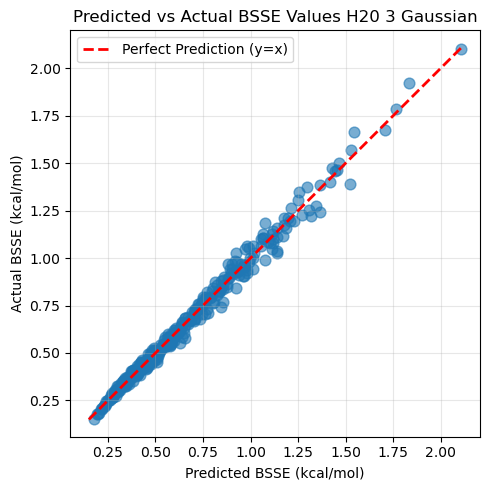

{'RMSE': np.float64(0.03403726922919982), 'MAE': np.float64(0.024375869439472432), '% Error': np.float64(3.783279628063642)}


In [24]:
for i in range(1, 4):
    fit_gauss = fit_gaussian(bsse_data_nwchem_kcal, i)
    print(
        predicted_v_actual_plot(bsse_data_nwchem_kcal, fit_gauss, f"H20 {i} Gaussian")
    )

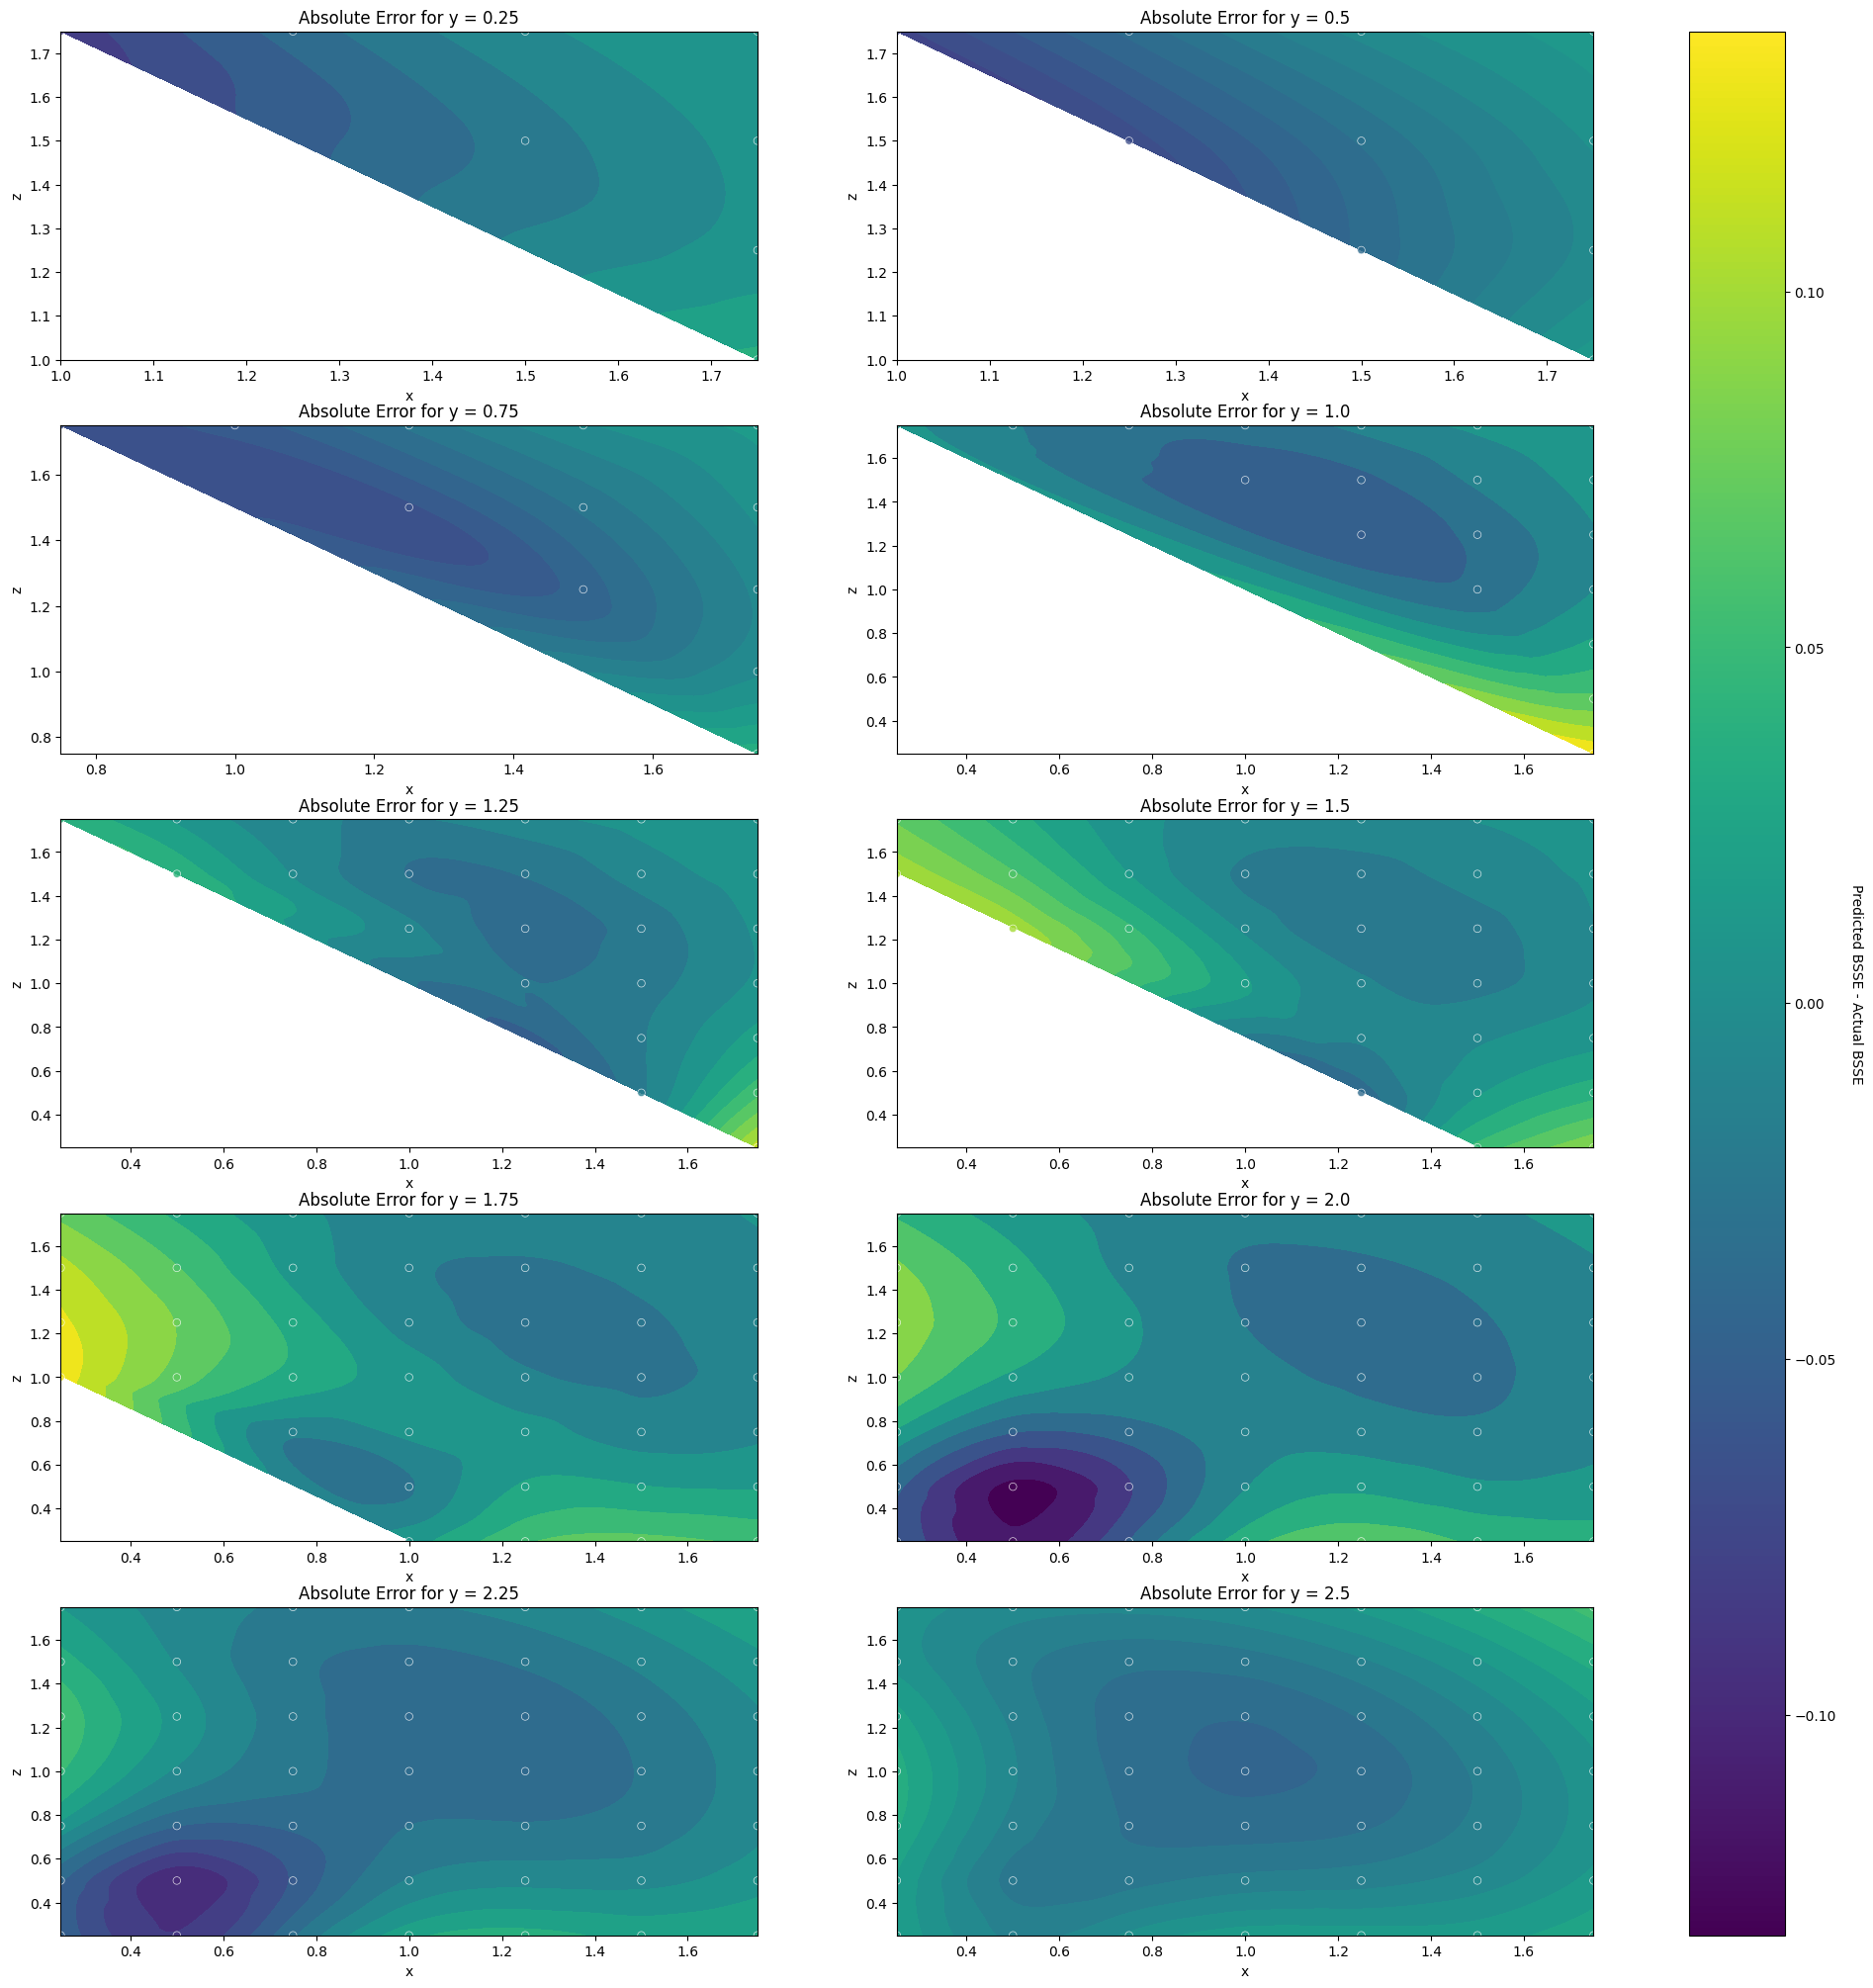

In [30]:
make_error_contour_plots(bsse_data_nwchem_kcal, fit_gauss)

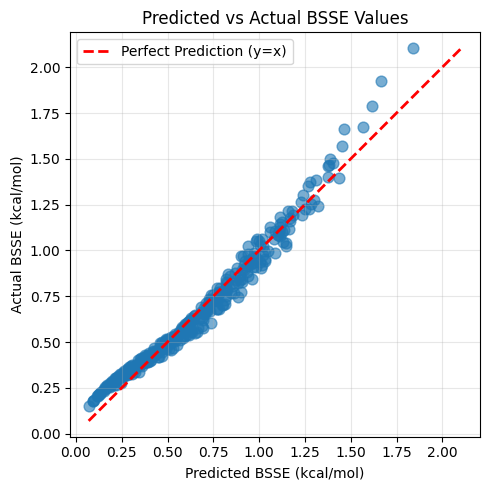

/Users/ibrahims/Documents/Programming/undergrad_reasearch/ames_research_summer_2025/psi4/docstring_stuff/src/bsse_calculator/plotting_helpers.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff, var_matrix = curve_fit(gauss, coords, bsses, p0=p0, maxfev=10000)


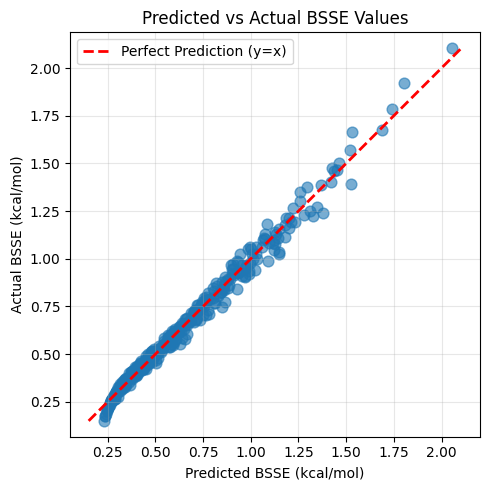

/Users/ibrahims/Documents/Programming/undergrad_reasearch/ames_research_summer_2025/psi4/docstring_stuff/src/bsse_calculator/plotting_helpers.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff, var_matrix = curve_fit(gauss, coords, bsses, p0=p0, maxfev=10000)


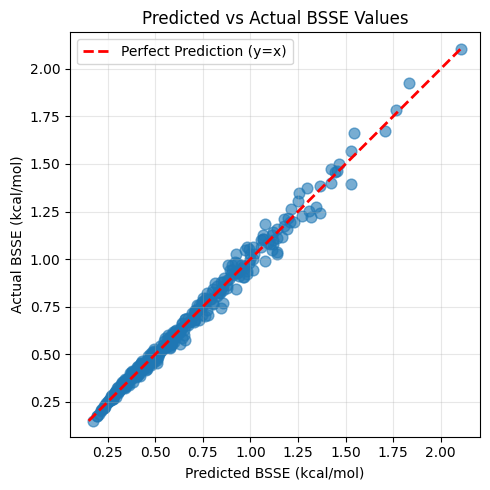

/Users/ibrahims/Documents/Programming/undergrad_reasearch/ames_research_summer_2025/psi4/docstring_stuff/src/bsse_calculator/plotting_helpers.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff, var_matrix = curve_fit(gauss, coords, bsses, p0=p0, maxfev=10000)


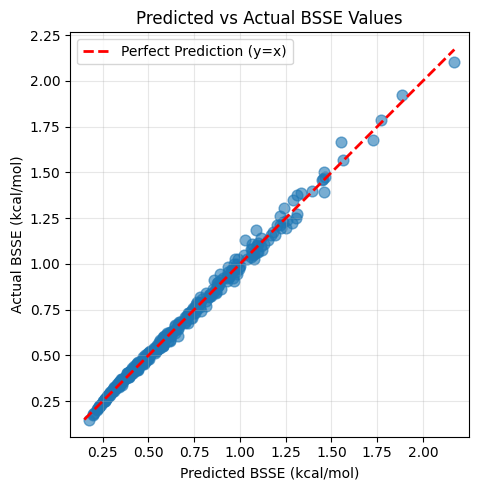

/Users/ibrahims/Documents/Programming/undergrad_reasearch/ames_research_summer_2025/psi4/docstring_stuff/src/bsse_calculator/plotting_helpers.py:77: OptimizeWarning: Covariance of the parameters could not be estimated
  coeff, var_matrix = curve_fit(gauss, coords, bsses, p0=p0, maxfev=10000)


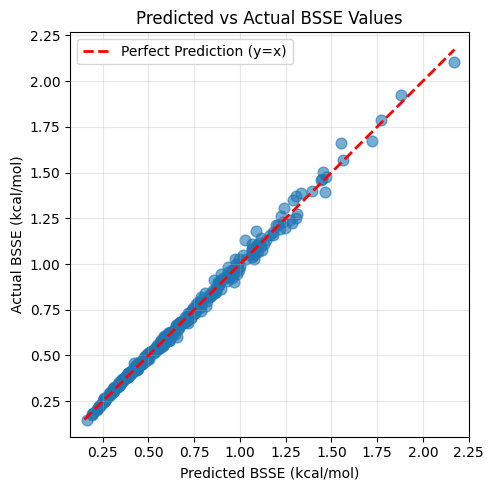

{1: np.float64(9.764837917990958),
 2: np.float64(4.56268641657539),
 3: np.float64(3.7731741305358537),
 4: np.float64(2.420064871153486),
 5: np.float64(2.1907192658988817)}

In [31]:
graph_data = {}
for num_gaussians in range(1, 6):
    fit_gauss = fit_gaussian(bsse_data_nwchem_kcal, num_gaussians)
    percent_error = predicted_v_actual_plot(bsse_data_nwchem_kcal, fit_gauss)["% Error"]
    graph_data[num_gaussians] = percent_error
graph_data

In [32]:
graph_data = pd.DataFrame.from_dict(graph_data, orient="index")

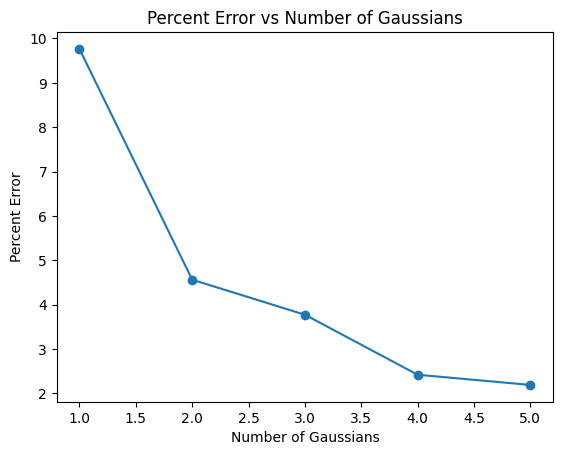

In [36]:
plt.plot(graph_data.index, graph_data[0], marker="o")
plt.xlabel("Number of Gaussians")
plt.ylabel("Percent Error")
plt.title("Percent Error vs Number of Gaussians")
plt.show()

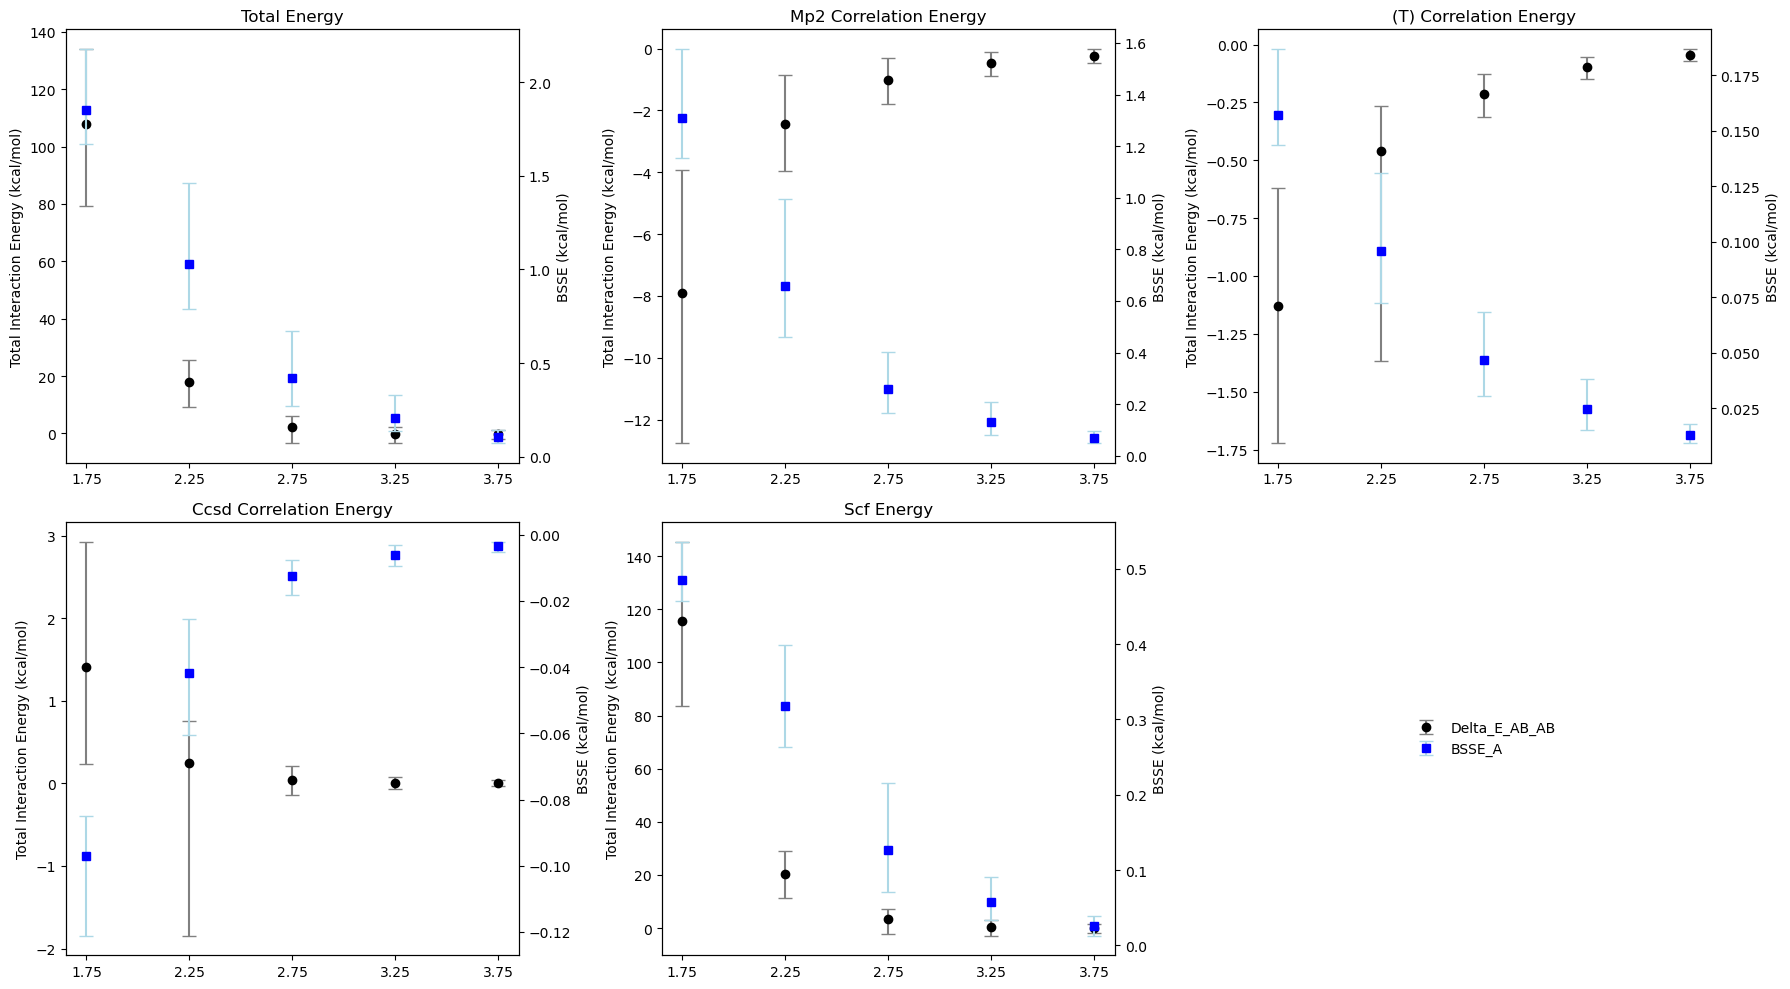

In [1]:
from bsse_calculator.plotting_helpers import *

grouped_df = create_df_euler_angles("water_dimer_energies_euler.json")
plot_energy_vs_bsse_euler_angles(grouped_df)

/Users/ibrahims/Documents/Programming/undergrad_reasearch/ames_research_summer_2025/psi4/docstring_stuff/src/bsse_calculator/plotting_helpers.py:850: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  energy_types_df = pd.concat([energy_types_df, df], axis=0)
/Users/ibrahims/Documents/Programming/undergrad_reasearch/ames_research_summer_2025/psi4/docstring_stuff/src/bsse_calculator/plotting_helpers.py:828: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  energy_types_df = pd.concat([energy_types_df, df]

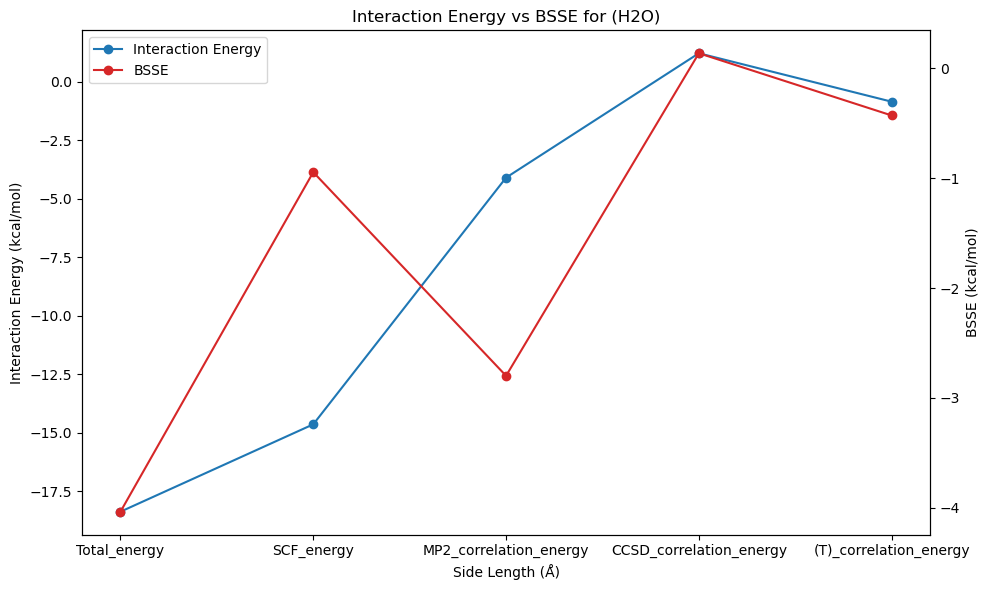

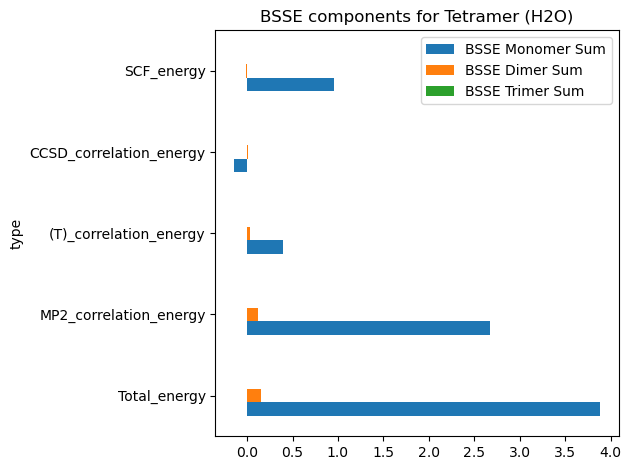

In [1]:
import json
from bsse_calculator.plotting_helpers import *

energy_dfs = plot_interaction_v_bsse("water_tetramer_singlepoint.json", "H2O")
plot_bsse_components("water_tetramer_singlepoint.json", "H2O")

In [2]:
geometry = [
    [
        "O 1.43578615 -1.81362614 0.02883928",
        "H 0.51948659 -2.05981895 0.27379913",
        "H 1.97323208 -1.99738588 0.80705304",
    ],
    [
        "O -0.20046914 0.37272269 -0.86419396",
        "H 0.63389482 -0.08242954 -0.65336297",
        "H -0.11854055 1.27366879 -0.50868257",
    ],
    [
        "O -1.33729724 -1.77663235 0.40232204",
        "H -1.94652043 -2.27621778 -0.15290166",
        "H -1.18633327 -0.92442897 -0.06636188",
    ],
    [
        "O 0.02509624 3.08759520 0.11490845",
        "H 0.17771767 3.32038150 1.03857842",
        "H 0.52221739 3.73343873 -0.40131992",
    ],
]


def get_center_of_mass(mol):
    points = np.array([[float(x) for x in line.split()[1:]] for line in mol])
    return np.mean(points, axis=0)


center_of_masses = np.array([get_center_of_mass(mol) for mol in geometry])

In [3]:
coords = {
    "A": center_of_masses[0],
    "B": center_of_masses[1],
    "C": center_of_masses[2],
    "D": center_of_masses[3],
}

In [11]:
def get_basis_from_closest(closest_list, monomers, n):
    basis = set(monomers)
    while len(basis) < n:
        closest = closest_list.pop()
        basis.add(closest)
    return "".join(sorted(basis))


def get_n_closest(monomers, n, coords):
    monomers_center_of_mass = np.mean([coords[monomer] for monomer in monomers], axis=0)
    distances = np.linalg.norm(
        monomers_center_of_mass - np.array(list(coords.values())), axis=1
    )
    closest_n = np.argsort(distances)
    basis = get_basis_from_closest(
        [list(coords.keys())[closest] for closest in closest_n], monomers, n
    )
    if len(monomers) == 1:
        return f"E({basis})_{monomers}"
    else:
        return f"Delta_E({basis})_{monomers}"


def get_energy_type_calculation(df, monomers, energy_type, n, coords):
    if n == 0:
        return 0
    else:
        return df[get_n_closest(monomers, n, coords)][energy_type]


def get_energy_type_calculation(df, monomers, energy_type, n, coords):
    if n == 0:
        return 0
    else:
        return df[get_n_closest(monomers, n, coords)][energy_type]


def estimate_monomers_energy(df, monomers, levels, coords):
    assert len(monomers) <= min(
        [4] + [value for value in levels.values() if value != 0]
    ), "Too many monomers"
    return sum(
        get_energy_type_calculation(df, monomers, energy_type, n, coords)
        for energy_type, n in levels.items()
    )

/Users/ibrahims/Documents/Programming/undergrad_reasearch/ames_research_summer_2025/psi4/docstring_stuff/src/bsse_calculator/plotting_helpers.py:845: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  energy_types_df = pd.concat([energy_types_df, df], axis=0)


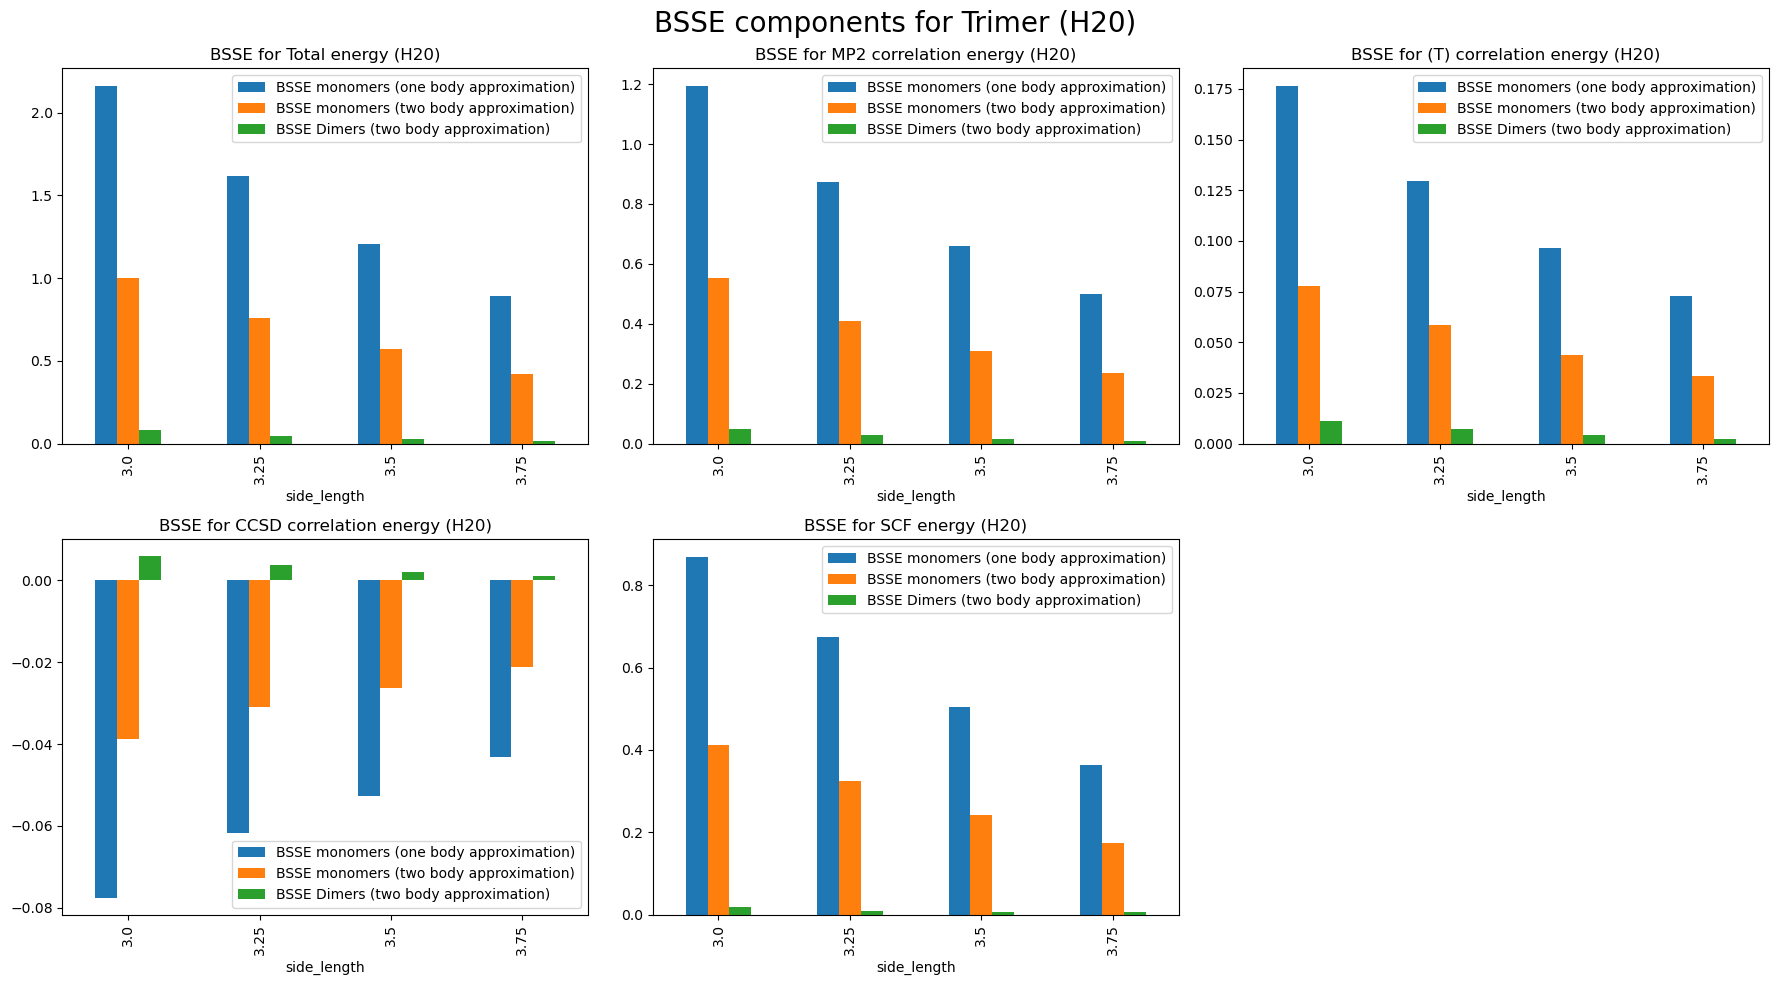

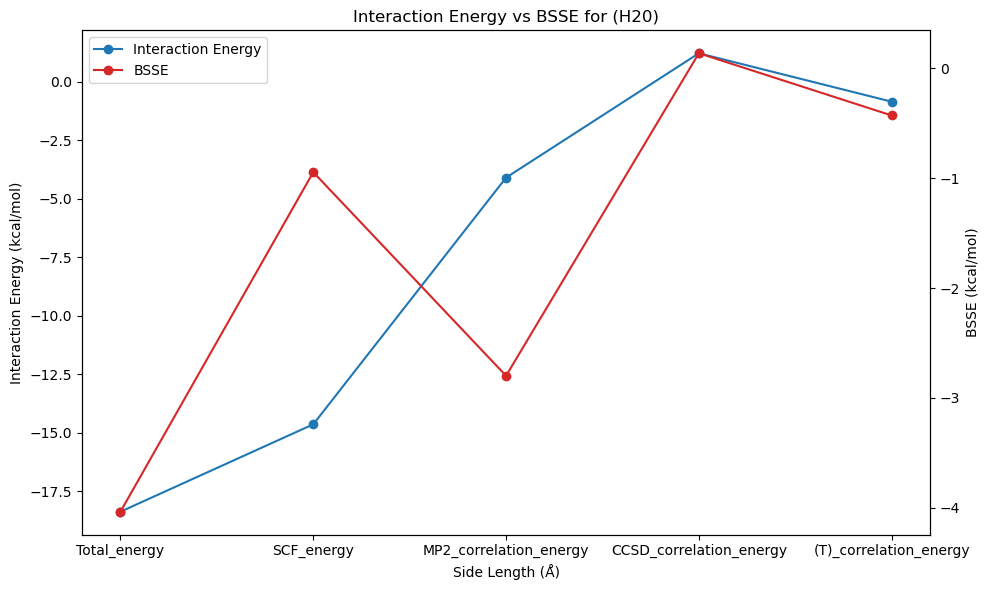

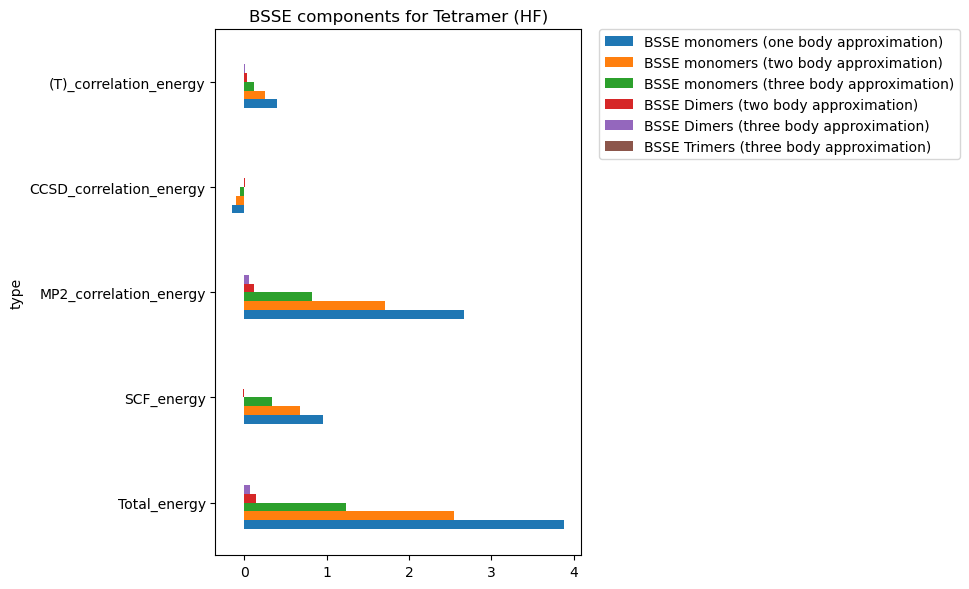

In [2]:
from bsse_calculator.plotting_helpers import *

plot_bsse_composition_trimer("water_trimer_energies.json", "H20")
plot_bsse_composition_tetramer("water_tetramer_singlepoint.json", "H20")

/Users/ibrahims/Documents/Programming/undergrad_reasearch/ames_research_summer_2025/psi4/docstring_stuff/src/bsse_calculator/plotting_helpers.py:845: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  energy_types_df = pd.concat([energy_types_df, df], axis=0)


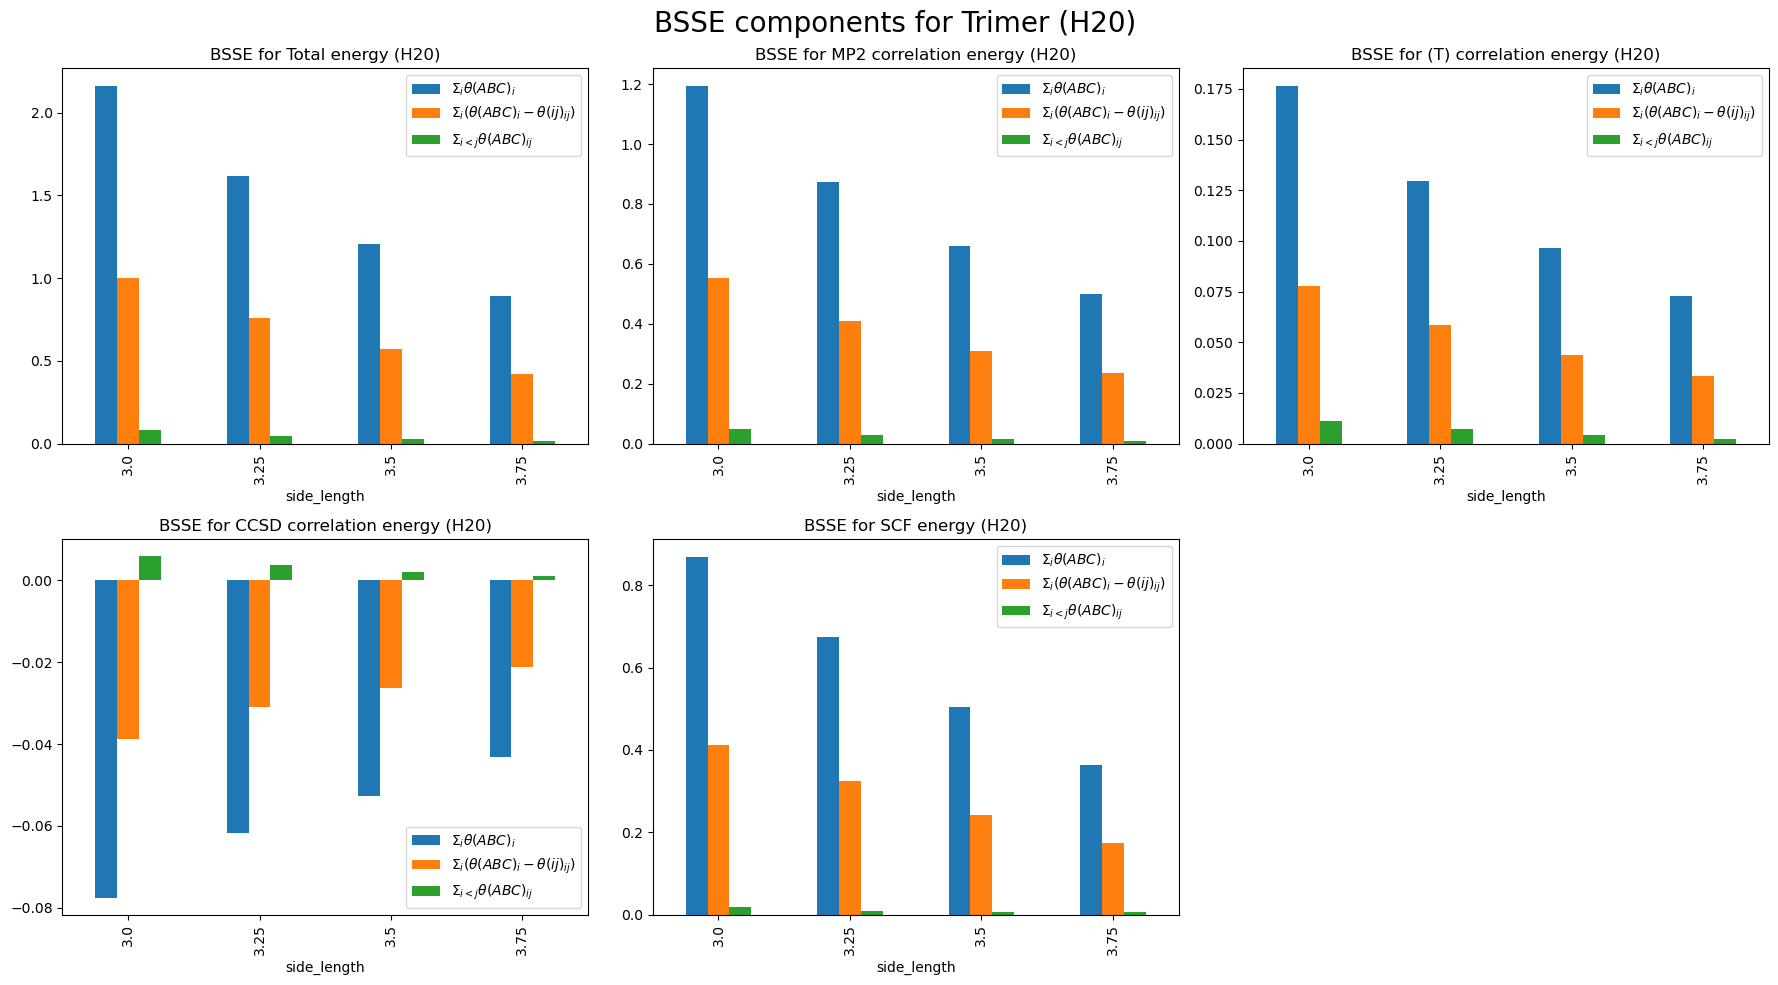

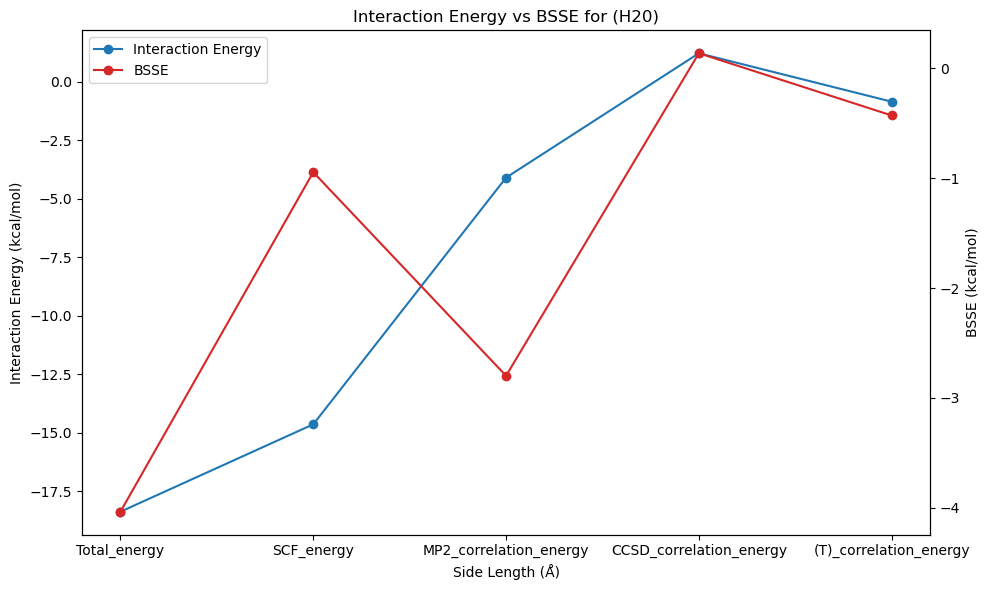

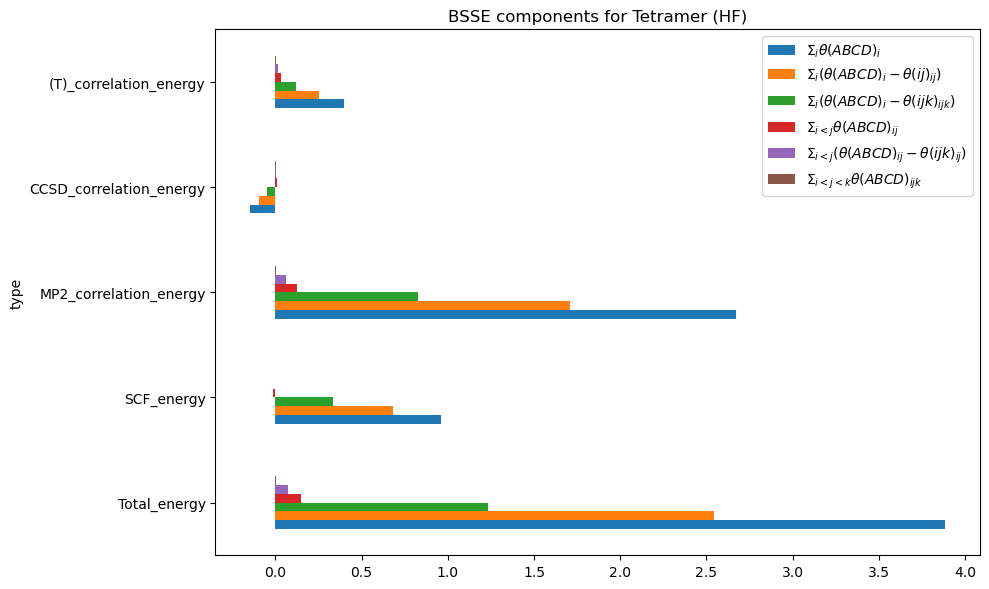

In [1]:
from bsse_calculator.plotting_helpers import *

plot_bsse_composition_trimer("water_trimer_energies.json", "H20")
plot_bsse_composition_tetramer("water_tetramer_singlepoint.json", "H20")

In [ ]:
# estimate trimer interaction energy as just SCF energy in trimer basis (3,0,0,0)
# estimate dimer interaction energy as just SCF energy in trimer basis (2,0,0)
# estimate monomer energies with 4,2,1,1

# we need CCSD(t) of each monomer
# MP2 for 4 monomers in 4 dimers basis covering 4 monomers
# SCF for each monomer in the tetramer basis
# SCF for each dimer in the dimer basis
# SCF for each trimer in the trimer basis

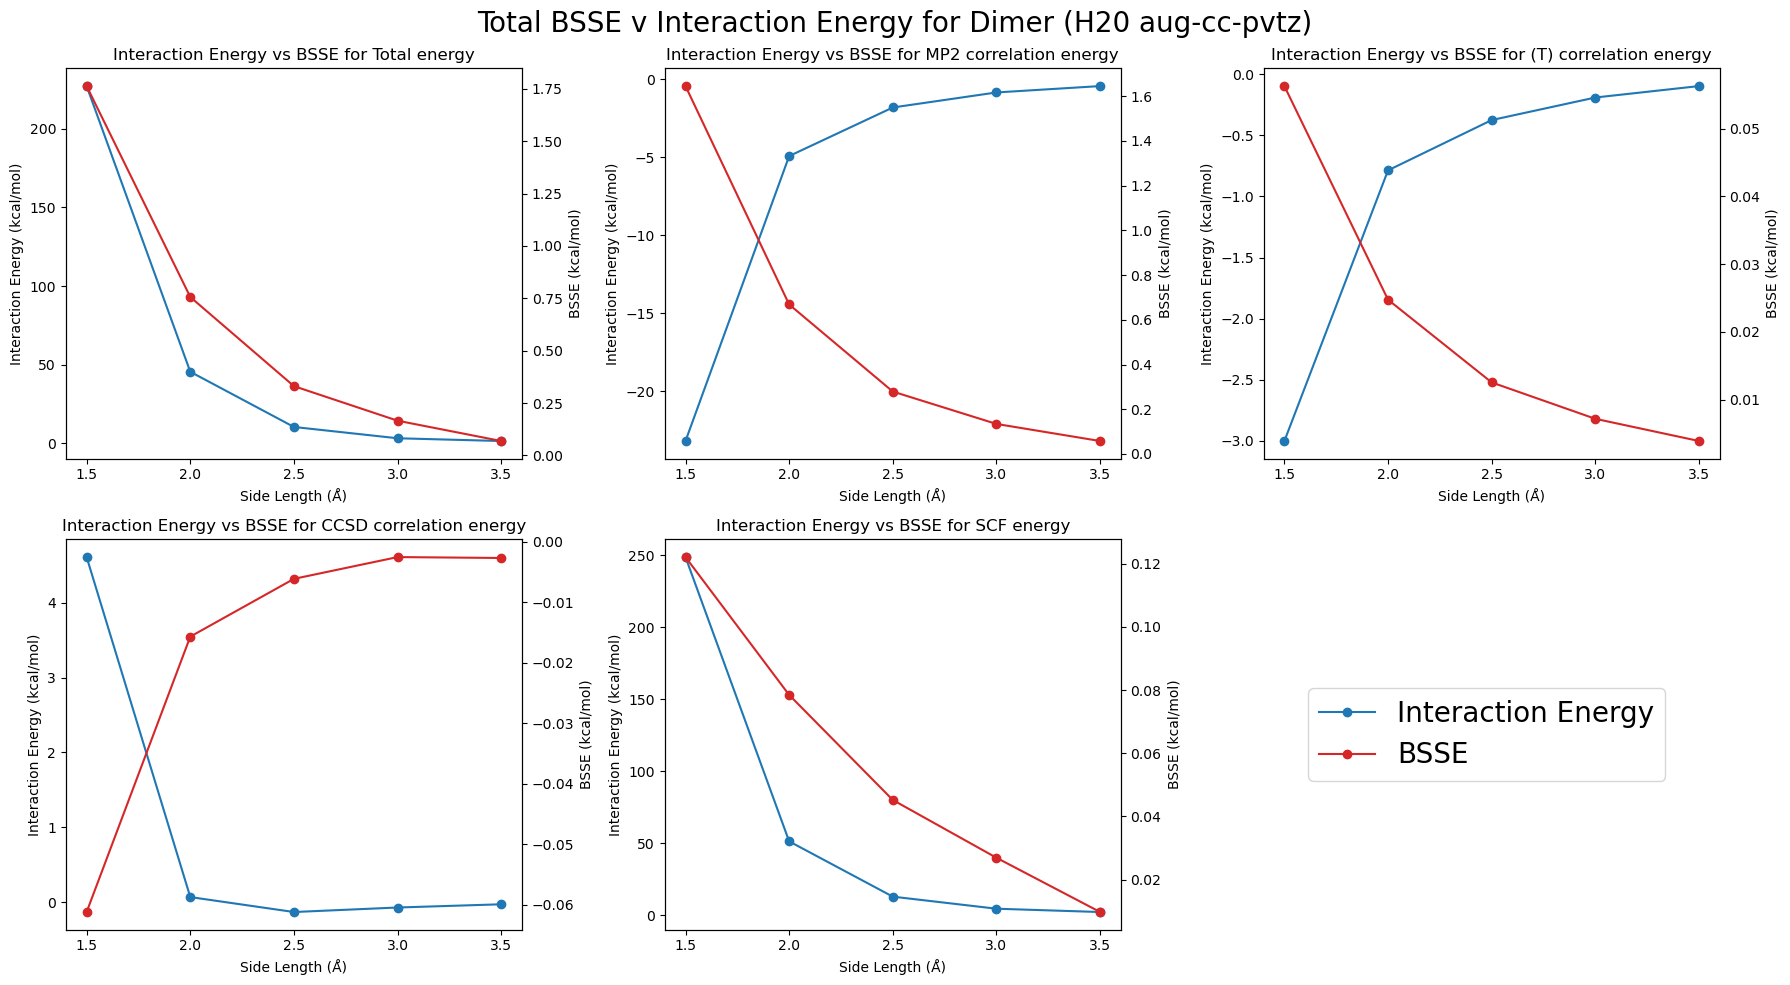

In [2]:
import json
from bsse_calculator.plotting_helpers import *

with open("H20_dimer_energies_pvtz.json", "r") as f:
    data = json.load(f)
energy_types = [
    key.replace("_Delta_E_AB_AB", "")
    for key in next(iter(data.values())).keys()
    if key.endswith("_Delta_E_AB_AB")
]
regrouped_energies = defaultdict(list)
for side_length in data.keys():
    for energy_type in energy_types:
        row = {"side_length": side_length}
        for calculation in data[side_length].keys():
            if calculation.startswith(energy_type):
                row[calculation.replace(f"{energy_type}_", "")] = (
                    data[side_length][calculation] * 627.5096
                )
        regrouped_energies[energy_type].append(row)
energy_dfs = {
    energy_type: pd.DataFrame(regrouped_energies[energy_type])
    for energy_type in energy_types
}
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for ax, (k, df) in zip(axes, energy_dfs.items()):
    formated_title = k.replace("_", " ")
    lines, labels = plot_dual_axis(
        df["Delta_E_AB_AB"],
        df["BSSE_A"],
        df["side_length"],
        ax1=ax,
        title=f"Interaction Energy vs BSSE for {formated_title}",
        x_label="Side Length (Å)",
        y1_label="Interaction Energy (kcal/mol)",
        y2_label="BSSE (kcal/mol)",
        label1="Interaction Energy",
        label2="BSSE",
    )
plt.suptitle("Total BSSE v Interaction Energy for Dimer (H20 aug-cc-pvtz)", fontsize=20)
plt.tight_layout()
ax.legend(
    lines, labels, prop={"size": 20}, loc="center left", bbox_to_anchor=(1.380, 0.5)
)
fig.delaxes(axes[-1])